In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from damon_mhr import DamonMHRDataset

import numpy as np 
from matplotlib import pyplot as plt
import random
import cv2

import viser
import time

from better_human.smpl import SMPL
from better_human.smpl.visualize import visualize_single

import os

In [8]:
dataset = DamonMHRDataset(
    contact_npz_path='damon_mhr_contact/hot_dca_trainval_contact_lod6.npz',
    detect_npz_path='damon_mhr_contact/hot_dca_trainval_detect.npz',
    data_root='/media/rikhat/Hard/datasets/DECO/',
    lod=6
)

Loading Damon MHR contact dataset from damon_mhr_contact/hot_dca_trainval_contact_lod6.npz
  Loading detect data from damon_mhr_contact/hot_dca_trainval_detect.npz
  Bounding boxes and camera intrinsics available
Loaded 4384 samples | LOD6 (595 verts) | total contact vertices: 392885 | avg per sample: 89.6


4384
tensor(306.1599)


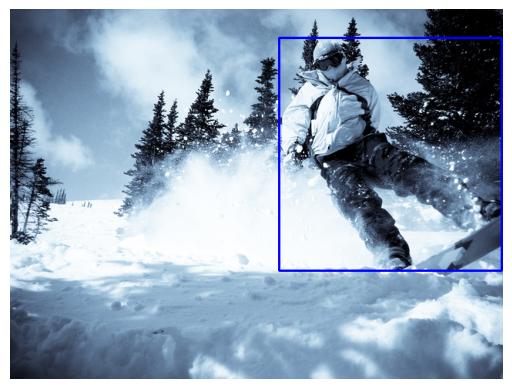

In [9]:
print(len(dataset))

id = random.randint(0, len(dataset))

(image, bbox, cam_k), contact_label = dataset[id]
image = np.array(image)

bbox = bbox.numpy().astype(np.int32)
print(cam_k[0, 0])

cv2.rectangle(image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 0, 255), 2)

plt.imshow(image)
plt.axis('off')
plt.show()



In [10]:
contact_label.shape


torch.Size([595])

In [51]:
smpl = SMPL("../../better_human/models/smpl/SMPL_NEUTRAL.npz")

dataset_path = "/data3/rikhat.akizhanov/DECO/"
masks_path = "damon_mhr_contact/masks_v2/trainval"

data_path = os.path.join(dataset_path, "datasets/Release_Datasets/damon", "hot_dca_trainval.npz")
data = np.load(data_path, allow_pickle=True)


for key in data.keys():
    print(key)

imgname
pose
transl
shape
cam_k
polygon_2d_contact
contact_label
scene_seg
part_seg
contact_label_smplx
contact_label_objectwise
contact_label_smplx_objectwise


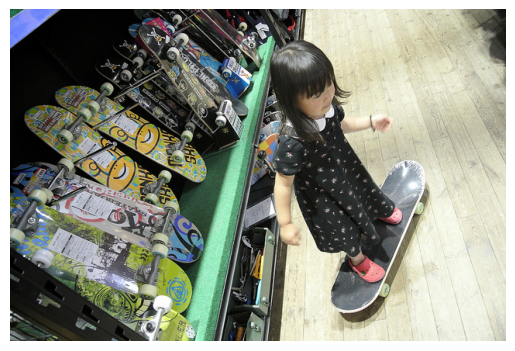

['imgname', 'object_names', 'metadata_version', 'contact_vertices_smpl_0', 'contact_vertices_mhr_0', 'contact_body_parts_0', 'bboxes_0', 'scores_0', 'best_detection_0', 'disambiguation_scores_0', 'contact_vertices_smpl_1', 'contact_vertices_mhr_1', 'contact_body_parts_1', 'bboxes_1', 'scores_1', 'best_detection_1', 'disambiguation_scores_1', 'num_detections']
['person' 'skateboard']
[]
[0.32797962 0.70173705 0.27429143 0.31505904 0.31829274 0.2815311
 0.29846227 0.3289621  0.26196498 0.27821732 0.32631794 0.30053222]


In [55]:
idx = 1

img_path = os.path.join(dataset_path, data["imgname"][idx])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

masks_dir = os.path.join(masks_path, f"{idx:04d}")
metadata = np.load(os.path.join(masks_dir, "metadata.npz"), allow_pickle=True)

print(metadata.files)
print(metadata["object_names"])
print(metadata[f"contact_vertices_smpl_{0}"])
print(metadata[f"disambiguation_scores_{1}"])